#

In [1]:
import numpy as np
import matplotlib.pyplot as plt
rng = np.random.default_rng()
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd

Word count matrix shape (passages x features): (1000, 6719)
Explained variance ratio of the first two principal components: [0.05423251 0.02831915]

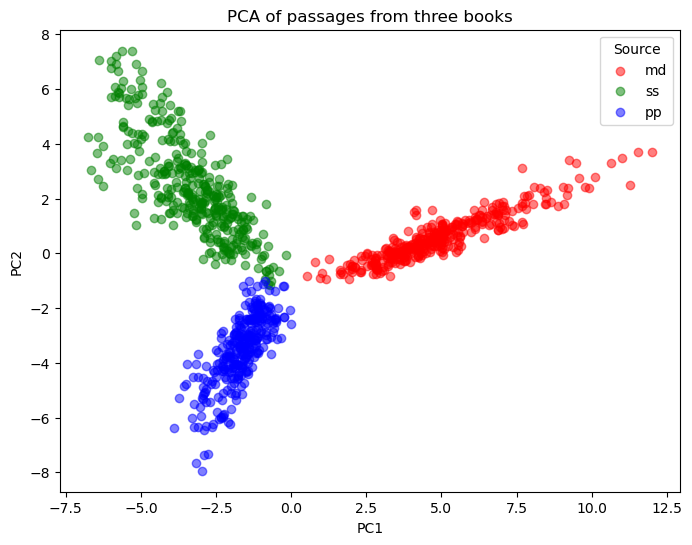

In [2]:

passages = open('passages.txt', 'r').read().splitlines()
sources = pd.read_csv('passage_sources.tsv', sep='\t')

# Vectorize
vectorizer = CountVectorizer(stop_words='english', min_df=5)
X = vectorizer.fit_transform(passages)
print('Word count matrix shape (passages x features):', X.shape)

#PCA
pca = PCA(n_components=2)
coords = pca.fit_transform(X.toarray())
print('Explained variance ratio of the first two principal components:', pca.explained_variance_ratio_)

#Scatter Plot
plt.figure(figsize=(8, 6))
colors = {'md': 'red', 'ss': 'green', 'pp': 'blue'}
for src in sources['source'].unique():
    idx = sources['source'] == src
    plt.scatter(coords[idx, 0], coords[idx, 1], label=src, alpha=0.5, color=colors[src])
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA of passages from three books')
plt.legend(title='Source')
plt.show()

In [7]:
X.toarray()

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(1000, 6719))

In [9]:
from collections import defaultdict

pfile = open("passages.txt", "r")
passages = pfile.read().split("\n")[:-1]
sources = pd.read_table("passage_sources.tsv")
words = np.unique(" ".join(passages).split(" "))[1:]
def tabwords(x, words):
    d = defaultdict(int)
    for w in x.split(" "):
        d[w] += 1
    out = np.array([d[w] for w in words])
    return out

wordmat = np.array([tabwords(x, words) for x in passages])

In [12]:
XX = wordmat[:, wordmat.max(axis=0) >= 5]

In [14]:
XX.shape, X.shape

((1000, 408), (1000, 6719))

In [ ]:
pca2 = PCA(n_components=2)
coords = pca2.fit_transform(wordmat.toarray())
print('Explained variance ratio of the first two principal components:', pca.explained_variance_ratio_)

#Scatter Plot
plt.figure(figsize=(8, 6))
colors = {'md': 'red', 'ss': 'green', 'pp': 'blue'}
for src in sources['source'].unique():
    idx = sources['source'] == src
    plt.scatter(coords[idx, 0], coords[idx, 1], label=src, alpha=0.5, color=colors[src])
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA of passages from three books')`v
plt.legend(title='Source')
plt.show()